Code for costly inference in Chapter 4 of Computational Foundations of Cognitive Neuroscience (https://gershmanlab.com/textbook/chapter4.pdf).

In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# set random seed for reproducibility
np.random.seed(42) 

In [ ]:
#---- Define functions ---

def von_mises_tuning(s, s_preferred, v, max_rate=15.0):
    response = np.exp(np.cos(s - s_preferred) / v)
    peak_response = np.exp(1.0 / v) 
    return max_rate * (response / peak_response)    # We normalize to maintain a consistent peak firing rate (max_rate) across conditions

def simulate_trial(theta_target, theta_distractor, v, n_neurons=50):
    # 1. Define Population
    s_prefs = np.linspace(0, 2*np.pi, n_neurons, endpoint=False)
    
    # 2. Generate Neural Response
    rates_target = von_mises_tuning(theta_target, s_prefs, v)
    spikes = np.random.poisson(rates_target)
    
    # 3. Decode
    rates_A = von_mises_tuning(theta_target, s_prefs, v)
    rates_B = von_mises_tuning(theta_distractor, s_prefs, v)
    
    rates_A = np.maximum(rates_A, 1e-9)
    rates_B = np.maximum(rates_B, 1e-9)
    
    log_likelihood_A = np.sum(spikes * np.log(rates_A) - rates_A)
    log_likelihood_B = np.sum(spikes * np.log(rates_B) - rates_B)
    
    llr = log_likelihood_A - log_likelihood_B
    
    # If the evidence is exactly equal (which happens when delta=0), we must guess randomly to simulate chance behavior.
    if np.isclose(llr, 0):
        return np.random.rand() > 0.5
    
    return llr > 0

In [ ]:

# --- Simulation Parameters ---
n_neurons = 50                                  # number of neurons
n_trials = 1000                                 # number of trials per condition
deltas = [0, 5, 10, 15, 20, 30, 45, 60, 90]     # angular differences in degrees
v_control = 0.2                                 # tuning width for control
v_fr = 0.6                                      # tuning width for food restricted

results_ctr = []
results_fr = []

# run simulation
for delta_deg in deltas:
    theta_target = np.pi 
    theta_dist = theta_target + np.deg2rad(delta_deg)
    
    # Control
    outcomes_ctr = [simulate_trial(theta_target, theta_dist, v_control, n_neurons) for _ in range(n_trials)]
    acc_ctr = np.mean(outcomes_ctr)
    results_ctr.append(acc_ctr)
    
    # Food Restricted
    outcomes_fr = [simulate_trial(theta_target, theta_dist, v_fr, n_neurons) for _ in range(n_trials)]
    acc_fr = np.mean(outcomes_fr)
    results_fr.append(acc_fr)

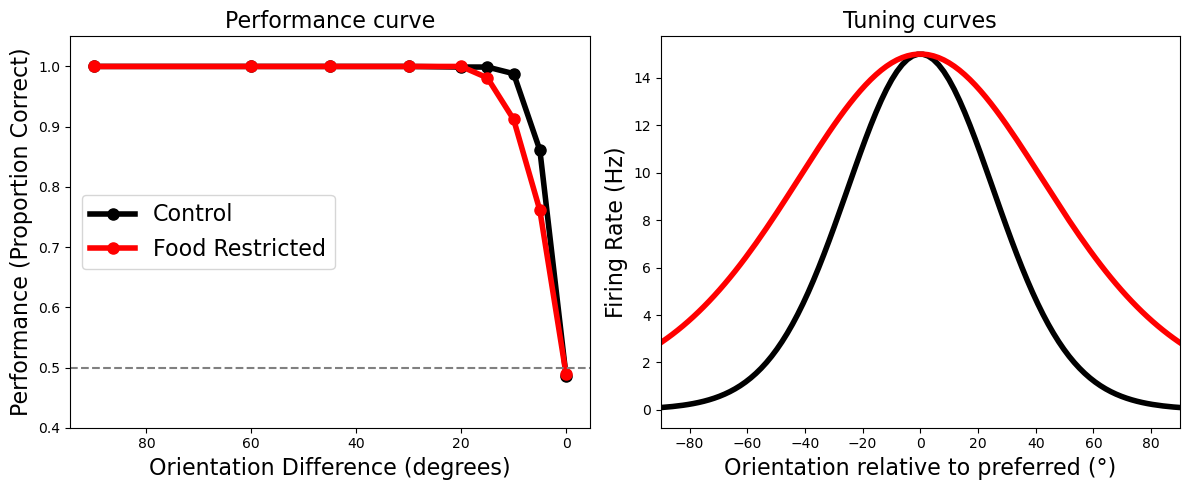

In [ ]:

# --- Plotting ---
plt.figure(figsize=(12, 5))

# Plot 1: Behavior
plt.subplot(1, 2, 1)
plt.plot(deltas, results_ctr,'-o', color='black', label='Control', linewidth=4, markersize=8)
plt.plot(deltas, results_fr, '-o', color='red', label='Food Restricted', linewidth=4, markersize=8)
plt.axhline(0.5, color='gray', linestyle='--')
plt.xlabel('Orientation Difference (degrees)', fontsize=16)
plt.ylabel('Performance (Proportion Correct)', fontsize=16)
plt.title('Performance curve', fontsize=16)
plt.legend(fontsize=16)
plt.ylim(0.4, 1.05)
plt.gca().invert_xaxis() 

# Plot 2: Tuning Curves
plt.subplot(1, 2, 2)
s_range = np.linspace(0, 2*np.pi, 200)
s_pref_single = np.pi 
resp_ctr = von_mises_tuning(s_range, s_pref_single, v_control)
resp_fr = von_mises_tuning(s_range, s_pref_single, v_fr)
x_degrees = np.rad2deg(s_range - s_pref_single)

plt.plot(x_degrees, resp_ctr, color='black', linewidth=4)
plt.plot(x_degrees, resp_fr, color='red', linewidth=4)
plt.xlabel('Orientation relative to preferred (°)', fontsize=16)
plt.ylabel('Firing Rate (Hz)', fontsize=16)
plt.title('Tuning curves', fontsize=16)
plt.xlim(-90, 90)

plt.tight_layout()
plt.savefig("costly_inference.pdf", bbox_inches='tight')